In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [3]:
DATA_DIR = Path("data")

SUBJECTS = [f"S{i}" for i in range(1, 8)]

features_list = []

for subject in [f"S{i}" for i in range(1, 8)]:

    file_path = DATA_DIR / f"{subject}_features.csv"

    if not file_path.exists():
        print(f"No encontrado: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Asegurar que el subject_id sea correcto
    df["subject_id"] = subject

    print(f"{subject}: {df.shape[0]} muestras")

    features_list.append(df)


# Unir todos los sujetos
features_all = pd.concat(
    features_list,
    ignore_index=True
)

print("\n==============================")
print("DATASET COMPLETO")
print("==============================")

print("Tamaño:", features_all.shape)

print("\nSujetos:")
print(features_all["subject_id"].value_counts().sort_index())

No encontrado: data\S1_features.csv
No encontrado: data\S2_features.csv
No encontrado: data\S3_features.csv
No encontrado: data\S4_features.csv
No encontrado: data\S5_features.csv
No encontrado: data\S6_features.csv
No encontrado: data\S7_features.csv


ValueError: No objects to concatenate

In [15]:
# ============================================================
# 4. DEFINIR LAS CARACTERÍSTICAS
# ============================================================

feature_cols = [
    "EOGh_mean",
    "EOGh_mav",
    "EOGh_rms",
    "EOGh_std",
    "EOGh_max",
    "EOGh_min",
    "EOGh_ptp",
    "EOGh_wl",

    "EOGv_mean",
    "EOGv_mav",
    "EOGv_rms",
    "EOGv_std",
    "EOGv_max",
    "EOGv_min",
    "EOGv_ptp",
    "EOGv_wl"
]


X = features_all[feature_cols]
y = features_all["label"]


In [16]:
# ============================================================
# 5. ELEGIR SUJETO DE PRUEBA
# ============================================================

TEST_SUBJECT = "S7"

train_df = features_all[
    features_all["subject_id"] != TEST_SUBJECT
].copy()

test_df = features_all[
    features_all["subject_id"] == TEST_SUBJECT
].copy()


# Datos de entrenamiento
X_train = train_df[feature_cols]
y_train = train_df["label"]


# Datos de prueba
X_test = test_df[feature_cols]
y_test = test_df["label"]


print("\n==============================")
print("CONJUNTO DE ENTRENAMIENTO")
print("==============================")

print("Sujetos:", train_df["subject_id"].unique())
print("Número de muestras:", len(train_df))


print("\n==============================")
print("CONJUNTO DE PRUEBA")
print("==============================")

print("Sujeto:", TEST_SUBJECT)
print("Número de muestras:", len(test_df))


CONJUNTO DE ENTRENAMIENTO
Sujetos: <StringArray>
['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
Length: 6, dtype: str
Número de muestras: 7515

CONJUNTO DE PRUEBA
Sujeto: S7
Número de muestras: 1250


In [17]:
# ============================================================
# 6. CREAR EL RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [18]:
# ============================================================
# 7. ENTRENAR EL MODELO
# ============================================================

rf.fit(X_train, y_train)

print("\nRandom Forest entrenado correctamente.")



Random Forest entrenado correctamente.


In [19]:
# ============================================================
# 8. REALIZAR PREDICCIONES
# ============================================================

y_pred = rf.predict(X_test)


RESULTADOS
Accuracy: 0.8792

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.86      0.84      0.85       246
           2       0.73      0.89      0.80       245
           3       0.95      0.89      0.92       759

    accuracy                           0.88      1250
   macro avg       0.85      0.87      0.86      1250
weighted avg       0.89      0.88      0.88      1250


Matriz de confusión:
[[206  23  17]
 [  8 217  20]
 [ 25  58 676]]


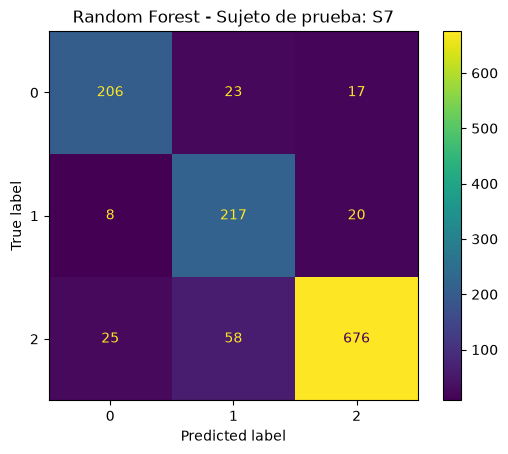

In [20]:
# ============================================================
# 9. ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("RESULTADOS")
print("==============================")

print(f"Accuracy: {accuracy:.4f}")


# ============================================================
# 10. REPORTE DE CLASIFICACIÓN
# ============================================================

print("\nReporte de clasificación:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 11. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(f"Random Forest - Sujeto de prueba: {TEST_SUBJECT}")

plt.show()



Importancia de las características:
      feature  importance
3    EOGh_std    0.182315
6    EOGh_ptp    0.161340
0   EOGh_mean    0.083382
1    EOGh_mav    0.079182
7     EOGh_wl    0.074951
2    EOGh_rms    0.055179
12   EOGv_max    0.052731
11   EOGv_std    0.050786
15    EOGv_wl    0.041194
8   EOGv_mean    0.038668
13   EOGv_min    0.037475
14   EOGv_ptp    0.034246
5    EOGh_min    0.030591
10   EOGv_rms    0.028189
4    EOGh_max    0.026564
9    EOGv_mav    0.023206


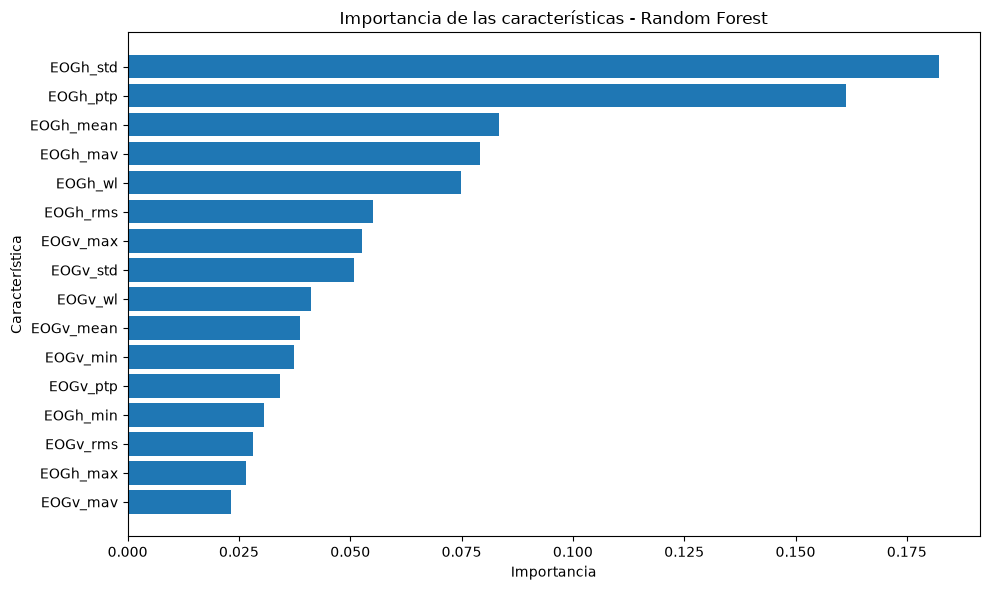

In [21]:
# ============================================================
# 12. IMPORTANCIA DE LAS CARACTERÍSTICAS
# ============================================================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("\nImportancia de las características:")
print(importance)


# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importancia")
plt.ylabel("Característica")

plt.title("Importancia de las características - Random Forest")

plt.tight_layout()

plt.show()